In [1]:
%cd ..
import pydicom
import os

/Users/anne-gabrielle/Le_Neuro/DeepMRAC


# Using ute_utils.py

In [2]:
from deepmrac.ute_utils import sort_files, load_data, to_dcm
from deepmrac.predictions import predict_DeepUTE

In [6]:
tmpdir="./temp_file"
ute1_path="./datasets/REMIND_022/ute/MRAC_UTE_0019"
ute2_path="./datasets/REMIND_022/ute/MRAC_UTE_0020"
umap_path="./datasets/REMIND_022/ute/MRAC_UTE_UMAP_0021"
version="VE11P"
verbose=True
output_folder=f"./output/ute_original"

In [7]:
# Sort files into specific folders
sort_files(source_folder=ute1_path, temp_subfolder=f"{tmpdir}/ute1_dcm", verbose=verbose )
sort_files(source_folder=ute2_path, temp_subfolder=f"{tmpdir}/ute2_dcm", verbose=verbose )
sort_files(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose )
        

Processing files in: ./datasets/REMIND_022/ute/MRAC_UTE_0019
Processing files in: ./datasets/REMIND_022/ute/MRAC_UTE_0020
Processing files in: ./datasets/REMIND_022/ute/MRAC_UTE_UMAP_0021


In [8]:
# Load data
ute1, ute2 = load_data(temp_folder=tmpdir)

In [9]:
pred = predict_DeepUTE(ute1=ute1, ute2=ute2, version=version)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [10]:
to_dcm(DeepX=pred, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=output_folder)

# Using image_processing.py

In [11]:
from deepmrac.image_processing import sort_dicomfiles, load_and_resample_images, resample_to_output_format, convert_dicom_to_nifti, to_dcm
from deepmrac.predictions import predict_DeepUTE
import nibabel as nib

In [15]:
tmpdir="./temp_file2"
ute1_path="./datasets/REMIND_022/ute/MRAC_UTE_0019"
ute2_path="./datasets/REMIND_022/ute/MRAC_UTE_0020"
umap_path="./datasets/REMIND_022/ute/MRAC_UTE_UMAP_0021"
verbose=True
version='VE11P'
output_folder=f"./output/ute"

In [16]:
# Sort files into specific folders
sort_dicomfiles(source_folder=ute1_path, temp_subfolder=f"{tmpdir}/ute1_dcm", verbose=verbose )
sort_dicomfiles(source_folder=ute2_path, temp_subfolder=f"{tmpdir}/ute2_dcm", verbose=verbose )
sort_dicomfiles(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose )

Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2021072110501049449925806.0.0.0 (192 images)
Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2021072110501049451125807.0.0.0 (192 images)
Principal Serie identified : 1.3.12.2.1107.5.2.38.51018.2021072110563345075128689.0.0.0 (192 images)


In [17]:
convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/ute1_dcm", output_nii=f"{tmpdir}/ute1.nii.gz", verbose=verbose)
convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/ute2_dcm", output_nii=f"{tmpdir}/ute2.nii.gz", verbose=verbose)
convert_dicom_to_nifti(dicom_dir=f"{tmpdir}/umap_dcm", output_nii=f"{tmpdir}/umap.nii.gz", verbose=verbose)

Converting ./temp_file2/ute1_dcm to ./temp_file2/ute1.nii.gz
Converting ./temp_file2/ute2_dcm to ./temp_file2/ute2.nii.gz
Converting ./temp_file2/umap_dcm to ./temp_file2/umap.nii.gz


In [18]:
ute1_rsl, ute1_ref = load_and_resample_images(nii_image=f"{tmpdir}/ute1.nii.gz", verbose=verbose)
ute2_rsl, ute2_ref = load_and_resample_images(nii_image=f"{tmpdir}/ute2.nii.gz", verbose=verbose)
umap_nat = nib.load(f'{tmpdir}/umap.nii.gz')

Loading and resampling data from ./temp_file2/ute1.nii.gz.
Loading and resampling data from ./temp_file2/ute2.nii.gz.


In [19]:
pred = predict_DeepUTE(ute1=ute1_rsl, ute2=ute2_rsl, version=version)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [20]:
pred_nii = nib.Nifti1Image(pred, ute1_ref.affine, ute1_ref.header)
os.makedirs(output_folder, exist_ok=True)
nib.save(pred_nii, f"{output_folder}/DeepUTE_before_resize.nii.gz")
DeepX = resample_to_output_format(pred_nii=pred_nii, umap_native=umap_nat, verbose=verbose, output_file=f"{output_folder}/DeepUTE.nii.gz")

Resampling to Umap format.
Saving QC nii file to ./output/ute/DeepUTE.nii.gz.


In [22]:
to_dcm(DeepX_nii=DeepX, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=output_folder, rmi_type="UTE")

# Visualisation

In [28]:
from deepmrac.plots import load_dicom_volume_and_aspects, plot_3d_views, load_nifti_volume_and_aspects

## Deep learning outcom

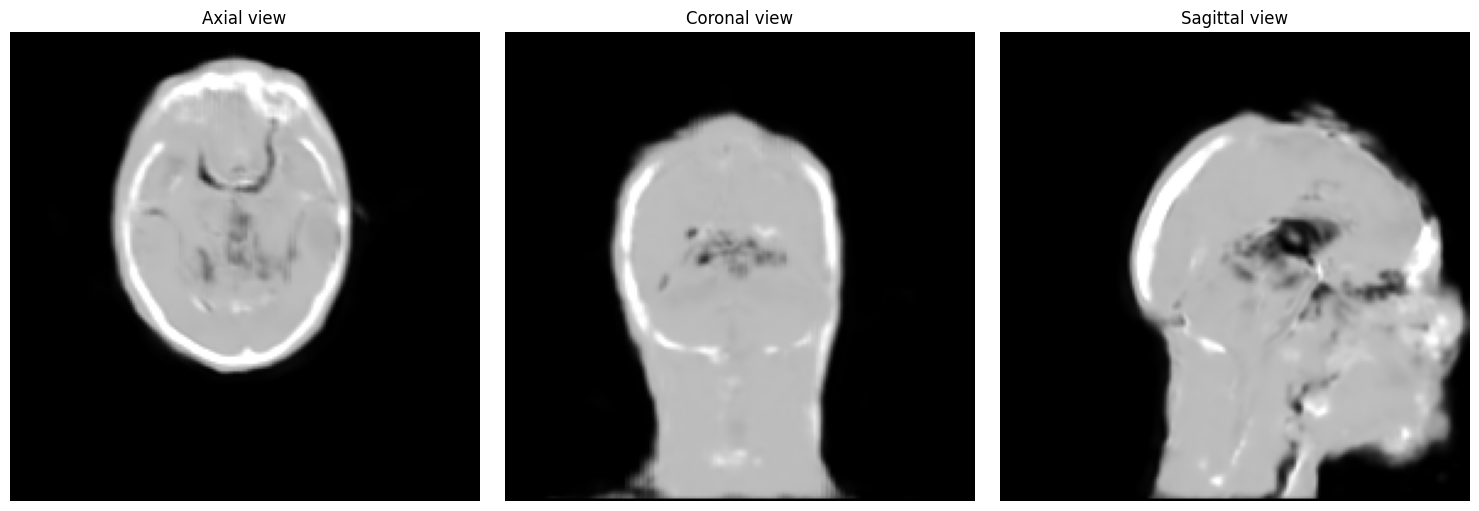

In [25]:
volume, aspects = load_nifti_volume_and_aspects("./output/ute/DeepUTE.nii.gz")
plot_3d_views(volume=volume, aspects=aspects)

## Original Umaps

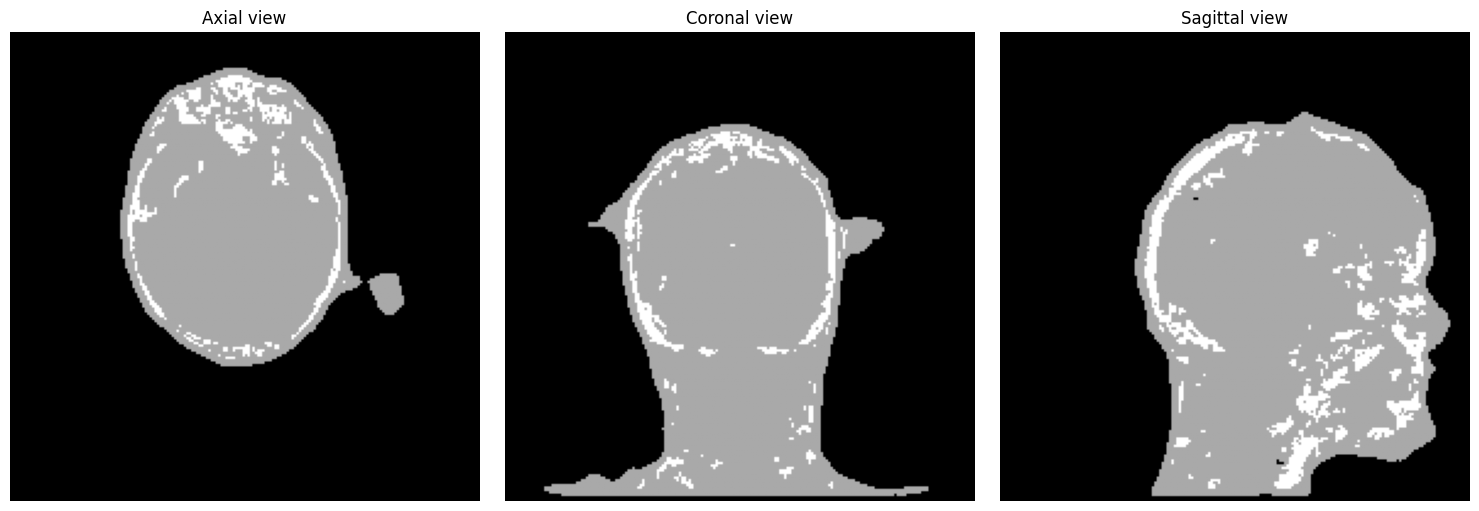

In [30]:
volume, aspects = load_dicom_volume_and_aspects("./datasets/REMIND_022/ute/MRAC_UTE_UMAP_0021")
plot_3d_views(volume=volume, aspects=aspects)

## UTE dicoms

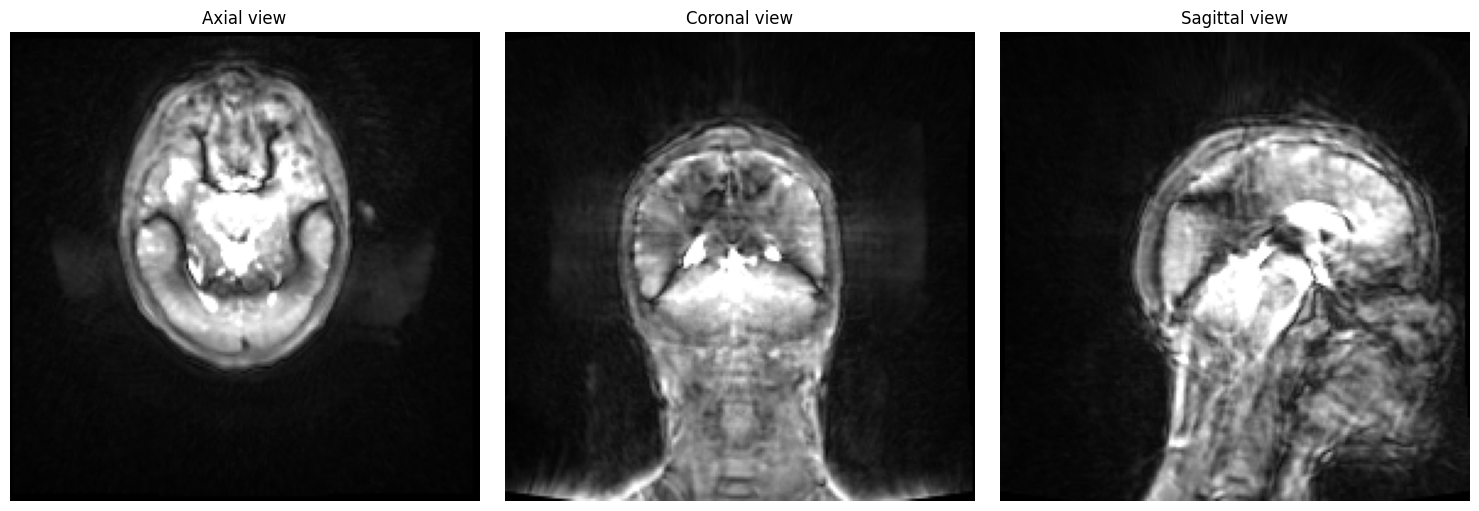

In [31]:
volume, aspects = load_dicom_volume_and_aspects("./datasets/REMIND_022/ute/MRAC_UTE_0019")
plot_3d_views(volume=volume, aspects=aspects)